<a href="https://colab.research.google.com/github/Solipcist/CODING-PRACTI/blob/main/A4LinearRegression_Sklearn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In this code, we're going to explore linear regression, a fundamental machine learning technique, using a dataset related to diabetes. Our goal is to build a model that can predict a patient's disease progression based on several patient attributes.

**Step 1: Loading the Diabetes Dataset**

We start by importing the necessary libraries and loading the diabetes dataset. The dataset contains information about diabetes patients, and it will be our source of data for building the predictive model.

In [1]:
import pandas as pd
import numpy as np
from sklearn import datasets


diabetes = datasets.load_diabetes()


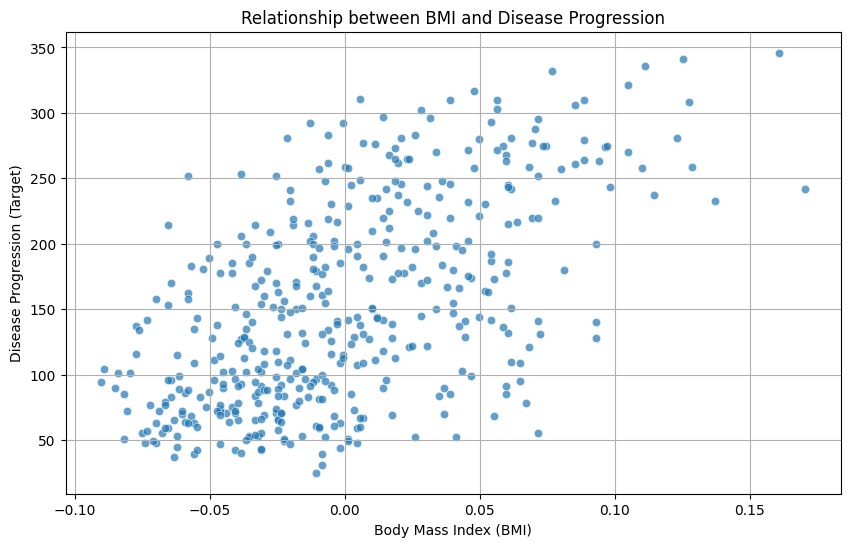

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x='bmi', y='target', data=df, alpha=0.7)
plt.title('Relationship between BMI and Disease Progression')
plt.xlabel('Body Mass Index (BMI)')
plt.ylabel('Disease Progression (Target)')
plt.grid(True)
plt.show()

In [11]:
display(df.describe())

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


In [10]:
display(df.head())

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


**Step 2: Displaying Dataset Information**

Before diving into the data, it's essential to understand what we're working with. We can use print(diabetes.DESCR) to display a description of the dataset. This description provides valuable information about the dataset's source, the meaning of each feature, and the target variable we want to predict.

In [2]:
print(diabetes.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

**Step 3: Creating a DataFrame**

To work with the data effectively, we create a DataFrame. A DataFrame is like a structured spreadsheet that allows us to organize and view the dataset more easily. In this case, we structure the data with columns for various patient attributes and a special "target" column representing the disease progression we want to predict.


In [3]:
import pandas as pd
import numpy as np

df = pd.DataFrame(data=np.c_[diabetes.data, diabetes.target], columns=diabetes.feature_names + ['target'])


**Step 4: Splitting Data for Training and Testing**

To build and evaluate our model, we need to split the dataset into two parts: one for training the model and the other for testing its performance. Typically, we use 80% of the data for training and 20% for testing.

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(diabetes.data, diabetes.target, test_size=0.2, random_state=0)


**Step 5: Creating a Linear Regression Model**

We're using a Linear Regression model to make predictions. The idea behind linear regression is to find a straight line (or hyperplane in higher dimensions) that best fits the relationship between the input features (patient attributes) and the target variable (disease progression).

In [5]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

**Step 6: Training the Model**

Now that our model is set up, we train it using the training data. This training process allows the model to learn the relationship between the input features and the target variable.

In [6]:
model.fit(X_train, y_train)

LinearRegression()

**Step 7: Making Predictions and Calculating Mean Squared Error (MSE)**

With the model trained, we can use it to make predictions on the test data. After making predictions, we calculate the Mean Squared Error (MSE). MSE measures how close our predictions are to the actual values, with lower values indicating better model performance.

In [7]:
from sklearn.metrics import mean_squared_error

y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)

**Step 8: Viewing Model Coefficients and Intercept**

Linear Regression provides coefficients for each feature and an intercept term. These coefficients represent the weight or importance of each feature in predicting the target variable.

In [8]:

print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)


Coefficients: [ -35.55025079 -243.16508959  562.76234744  305.46348218 -662.70290089
  324.20738537   24.74879489  170.3249615   731.63743545   43.0309307 ]
Intercept: 152.5380470138517


**Step 9: Visualizing Predictions**

To understand how well our model is performing, we create a scatter plot. This plot shows the actual disease progression values on one axis and the predicted values on the other. Ideally, we want the points to be close to a straight line, indicating accurate predictions.

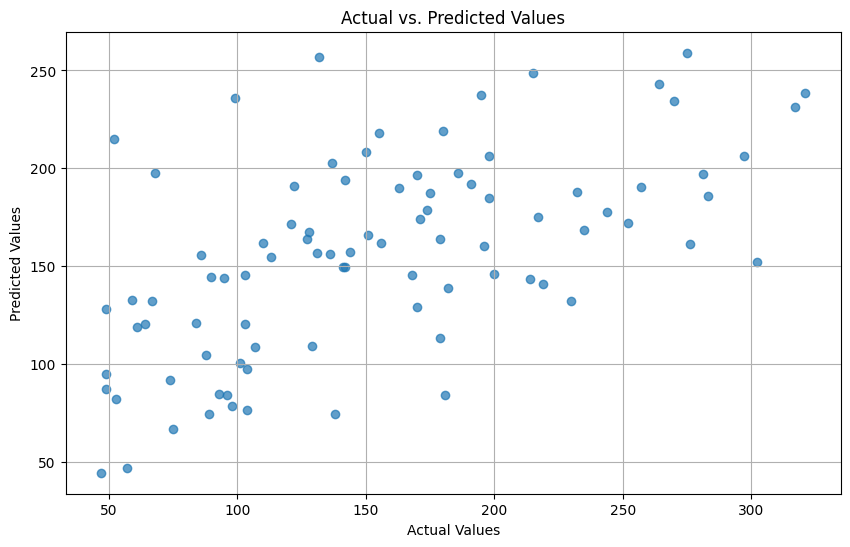

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted Values")
plt.grid(True)
plt.show()
